In [55]:
import pandas as pd

# Load the file
# 'sep' might need to be '\s+' if it uses multiple spaces instead of tabs
df = pd.read_csv('metal_eGFR_meta1.TBL.map.annot.gc.gz', sep='\s+', compression='gzip')

<>:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/z7/9ddbbmc16r938ffjjlj2ssv40000gn/T/ipykernel_94133/713784.py:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df = pd.read_csv('metal_eGFR_meta1.TBL.map.annot.gc.gz', sep='\s+', compression='gzip')


In [56]:
df.head()

,MarkerName,Allele1,Allele2,n,Freq1,Effect,StdErr,P.value,Direction,mac,chr,pos,P.value.GC,StdErr.GC,RSID
0,10:10000018:A_G,a,g,1062160.0,0.5719,-0.0008,0.0003,0.004116,--,9.094214e+05,10,10000018,0.01136,0.000340,rs6602381
1,10:100000625:A_G,a,g,1201910.0,0.5631,-0.0007,0.0003,0.004173,--,1.050229e+06,10,100000625,0.01148,0.000340,rs7899632
2,10:100000645:A_C,a,c,1201910.0,0.7974,-0.0008,0.0003,0.019440,--,4.870139e+05,10,100000645,0.03921,0.000340,rs61875309
3,10:100003242:G_T,t,g,1201920.0,0.8633,0.0002,0.0004,0.634100,-+,3.286049e+05,10,100003242,0.67450,0.000453,rs12258651
4,10:100003304:A_G,a,g,940166.0,0.9601,0.0007,0.0007,0.326400,++,7.502525e+04,10,100003304,0.38650,0.000793,rs72828461


In [85]:
df_renamed = df.rename(columns={
        "chr": "chromosome",
        "pos": "position",
        "RSID": "rsid",
        "MarkerName": "marker_name",
        "Allele1": "allele_1",
        "Allele2": "allele_2",
        "Effect": "beta",
        "P.value.GC": "p_value"
    })

In [58]:
df_filtered = (
    df
    .loc[df["P.value.GC"] < 5e-8]
    .rename(columns={
        "chr": "chromosome",
        "pos": "position",
        "RSID": "rsid",
        "MarkerName": "marker_name",
        "Allele1": "allele_1",
        "Allele2": "allele_2",
        "Effect": "beta",
        "P.value.GC": "p_value"
    })
    [
        ["chromosome", "position", "rsid", "marker_name", 
         "allele_1", "allele_2", "beta", "p_value"]
    ]
)

# Casting to categorical (equivalent to pl.Categorical)
df_filtered["chromosome"] = df_filtered["chromosome"].astype("category")

In [59]:
df_filtered.head()

,chromosome,position,rsid,marker_name,allele_1,allele_2,beta,p_value
1588,10,1003848,rs113185690,10:1003848:C_T,t,c,-0.0075,1.661000e-34
12060,10,104166464,rs3781292,10:104166464:A_G,a,g,0.0018,3.288000e-09
12061,10,104166466,rs3781291,10:104166466:G_T,t,g,-0.0018,3.972000e-09
12124,10,104201598,rs11191288,10:104201598:C_T,t,c,0.0016,3.248000e-08
13046,10,104547610,rs9419939,10:104547610:A_G,a,g,0.0028,1.923000e-13


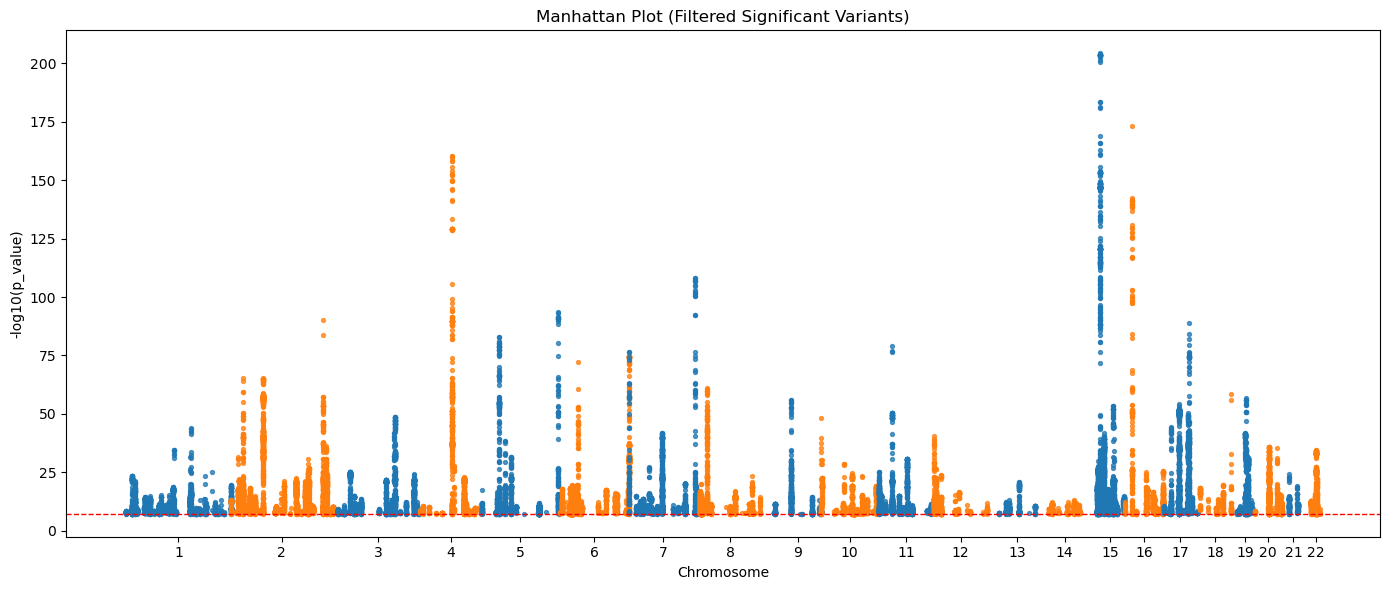

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Keep only required columns
m = df_filtered[['chromosome', 'position', 'p_value']].copy() # try and see how the plot looks for raw data with renamed cols (df_renamed)
m = m.dropna()

# Ensure numeric position and p-value
m['position'] = pd.to_numeric(m['position'], errors='coerce')
m['P.value.GC'] = pd.to_numeric(m['p_value'], errors='coerce')
m = m.dropna(subset=['position', 'p_value'])
m = m[m['p_value'] > 0]

# Chromosome ordering (1..22, then X, Y, MT)
chr_order = [str(i) for i in range(1, 23)] + ['X', 'Y', 'MT']
m['chromosome'] = m['chromosome'].astype(str).str.replace('chromosome', '', case=False, regex=False)
m = m[m['chromosome'].isin(chr_order)]
m['chromosome'] = pd.Categorical(m['chromosome'], categories=chr_order, ordered=True)
m = m.sort_values(['chromosome', 'position'])

# Build cumulative genomic position
chr_max = m.groupby('chromosome', observed=True)['position'].max().reset_index()
chr_max['offset'] = chr_max['position'].cumsum().shift(fill_value=0)
offset_map = dict(zip(chr_max['chromosome'].astype(str), chr_max['offset']))
m['x'] = m['position'] + m['chromosome'].astype(str).map(offset_map)

# Y-axis: -log10(p)
m['minus_log10_p'] = -np.log10(m['p_value'])

# X ticks at chromosome centers
chr_centers = []
for c in chr_order:
    sub = m[m['chromosome'].astype(str) == c]
    if len(sub):
        chr_centers.append((c, (sub['x'].min() + sub['x'].max()) / 2))

# Plot
plt.figure(figsize=(14, 6))
colors = ['#1f77b4', '#ff7f0e']
for i, c in enumerate(chr_order):
    sub = m[m['chromosome'].astype(str) == c]
    if len(sub):
        plt.scatter(sub['x'], sub['minus_log10_p'], s=8, color=colors[i % 2], alpha=0.75)

# Genome-wide significance line: p = 5e-8
plt.axhline(-np.log10(5e-8), color='red', linestyle='--', linewidth=1)

plt.xticks([x for _, x in chr_centers], [c for c, _ in chr_centers], rotation=0)
plt.xlabel('Chromosome')
plt.ylabel('-log10(p_value)')
plt.title('Manhattan Plot (Filtered Significant Variants)')
plt.tight_layout()
plt.show()

In [70]:
df_sorted = df_filtered.sort_values(['chromosome', 'position'])

In [71]:
df_sorted.head()

,chromosome,position,rsid,marker_name,allele_1,allele_2,beta,p_value
3162410,1,2035379,rs10910029,1:2035379:A_G,a,g,-0.0017,6.782000e-09
3162467,1,2035684,rs10910030,1:2035684:C_T,t,c,0.0017,5.966000e-09
3162510,1,2035799,rs10752741,1:2035799:A_G,a,g,0.0017,6.147000e-09
3162554,1,2035977,rs10752742,1:2035977:G_T,t,g,0.0017,5.847000e-09
3162598,1,2036263,rs10797413,1:2036263:A_G,a,g,0.0017,5.524000e-09


## Stage 2

In [73]:
df_sorted['locus_id'] = (
    (
        (df_sorted['position'].diff() > 500_000) | 
        (df_sorted['chromosome'] != df_sorted['chromosome'].shift(1))
    )
    .fillna(True)
    .astype(int)
    .cumsum()
)

In [84]:
df_sorted.head()

,chromosome,position,rsid,marker_name,allele_1,allele_2,beta,p_value,locus_id
3162410,1,2035379,rs10910029,1:2035379:A_G,a,g,-0.0017,6.782000e-09,1
3162467,1,2035684,rs10910030,1:2035684:C_T,t,c,0.0017,5.966000e-09,1
3162510,1,2035799,rs10752741,1:2035799:A_G,a,g,0.0017,6.147000e-09,1
3162554,1,2035977,rs10752742,1:2035977:G_T,t,g,0.0017,5.847000e-09,1
3162598,1,2036263,rs10797413,1:2036263:A_G,a,g,0.0017,5.524000e-09,1


## Stage 3

In [75]:
# Assuming df_loci is your Pandas DataFrame
lead_snps_df = (
    df_sorted
    .sort_values(["locus_id", "p_value"])
    .drop_duplicates(subset="locus_id", keep="first")
)

In [76]:
lead_snps_df.head()

,chromosome,position,rsid,marker_name,allele_1,allele_2,beta,p_value,locus_id
3170439,1,2060732,rs10797427,1:2060732:C_T,t,c,0.0017,3.993000e-09,1
3017539,1,15911947,rs45619934,1:15911947:G_T,t,g,-0.0030,2.985000e-24,2
3110577,1,18809916,rs12061708,1:18809916:A_G,a,g,-0.0022,5.155000e-13,3
3275931,1,23699340,rs2749153,1:23699340:A_G,a,g,-0.0030,3.883000e-22,4
3325900,1,27215079,rs34460334,1:27215079:C_T,t,c,-0.0034,5.612000e-10,5


In [77]:
from dataclasses import dataclass, asdict

@dataclass
class LeadSNP:
    """Prioritized SNP from GWAS analysis."""
    snp_id: str
    chromosome: str
    position: int
    p_value: float
    beta: float
    allele_1: str
    allele_2: str
    locus_id: str

In [80]:
lead_snps = [
    LeadSNP(
        snp_id=row.rsid if pd.notna(row.rsid) else row.marker_name,
        chromosome=row.chromosome,
        position=row.position,
        p_value=row.p_value,
        beta=row.beta,
        allele_1=row.allele_1,
        allele_2=row.allele_2,
        locus_id=f"LOCUS_{row.locus_id}",
    )
    for row in lead_snps_df.itertuples(index=False)
]

In [83]:
lead_snps[:5]

[LeadSNP(snp_id='rs10797427', chromosome=1, position=2060732, p_value=3.993e-09, beta=0.0017, allele_1='t', allele_2='c', locus_id='LOCUS_1'),
 LeadSNP(snp_id='rs45619934', chromosome=1, position=15911947, p_value=2.9849999999999998e-24, beta=-0.003, allele_1='t', allele_2='g', locus_id='LOCUS_2'),
 LeadSNP(snp_id='rs12061708', chromosome=1, position=18809916, p_value=5.155e-13, beta=-0.0022, allele_1='a', allele_2='g', locus_id='LOCUS_3'),
 LeadSNP(snp_id='rs2749153', chromosome=1, position=23699340, p_value=3.883e-22, beta=-0.003, allele_1='a', allele_2='g', locus_id='LOCUS_4'),
 LeadSNP(snp_id='rs34460334', chromosome=1, position=27215079, p_value=5.612e-10, beta=-0.0034, allele_1='t', allele_2='c', locus_id='LOCUS_5')]

## Stage 4

In [89]:
target_df = pd.DataFrame([asdict(snp) for snp in lead_snps])

In [90]:
target_df.head()

,snp_id,chromosome,position,p_value,beta,allele_1,allele_2,locus_id
0,rs10797427,1,2060732,3.993000e-09,0.0017,t,c,LOCUS_1
1,rs45619934,1,15911947,2.985000e-24,-0.0030,t,g,LOCUS_2
2,rs12061708,1,18809916,5.155000e-13,-0.0022,a,g,LOCUS_3
3,rs2749153,1,23699340,3.883000e-22,-0.0030,a,g,LOCUS_4
4,rs34460334,1,27215079,5.612000e-10,-0.0034,t,c,LOCUS_5


In [91]:
target_df.to_csv('kidney_targets.csv', index = False)